In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.api import VAR

from load import load_symbol_folder
from preprocess import build_merged
from cointegration import compute_mean_reverting_spread

In [2]:
- np.log(2) / np.log(0.9989057711592483)

633.1106024105044

In [2]:
start_date = "2024-07-22"
end_date = "2024-10-15"
cxw_data = load_symbol_folder("CXW_data", start_date=start_date, end_date=end_date)
geo_data = load_symbol_folder("GEO_data", start_date=start_date, end_date=end_date)

In [3]:
pdf = build_merged(geo_data, cxw_data)
pdf.head()

,mid_geo,mid_cxw
ts_event,,
2024-07-22 10:30:00,16.235,14.505
2024-07-22 10:31:00,16.250,14.505
2024-07-22 10:32:00,16.255,14.505
2024-07-22 10:33:00,16.260,14.520
2024-07-22 10:34:00,16.255,14.535


In [4]:
split_date = "2024-09-15"

train = pdf.loc[pdf.index < split_date].copy()
test = pdf.loc[pdf.index >= split_date].copy()

print("Train period:", train.index.min(), "→", train.index.max())
print("Test period :", test.index.min(), "→", test.index.max())
print("Train size:", len(train))
print("Test size :", len(test))

Train period: 2024-07-22 10:30:00 → 2024-09-13 14:59:00
Test period : 2024-09-16 10:30:00 → 2024-10-15 14:59:00
Train size: 10513
Test size : 5920


In [5]:
alpha, spread, kappa, theta, eigvals = compute_mean_reverting_spread(train, cols=("mid_geo", "mid_cxw"))

VAR(1) on ΔS_t results
A (intercept): [-0.00035143 -0.00012997]
B (lag-1 matrix):
 [[-0.08499795  0.08863903]
 [ 0.042407   -0.04107421]]

Derived kappa = (I - B)/dt:
 [[ 1.08499795 -0.08863903]
 [-0.042407    1.04107421]]
Derived theta = kappa^{-1} A dt: [-0.00033522 -0.0001385 ]

Eigenvalues of kappa: [1.12816088 0.99791129]
Chosen eigenvalue (fastest MR): 1.1281608760253825

Best linear combination (up to scale/sign):
  spread =  1.000000 * mid_geo  + -0.486952 * mid_cxw

Same combo normalized to second asset coefficient = 1:
  spread = -2.053592 * mid_geo  + 1.000000 * mid_cxw


c:\Users\Laurent Liao\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

def make_spread_from_alpha(df, alpha, cols=("mid_geo", "mid_cxw"), name="spread"):
    S = df[list(cols)].dropna()
    s = pd.Series(S.values @ alpha, index=S.index, name=name)
    return s.sort_index()

def clip_and_zscore_train_test(spread_train, spread_test, clip_q=(0.001, 0.999)):
    lo, hi = spread_train.quantile(list(clip_q))
    train_clip = spread_train.clip(lo, hi)
    mu = train_clip.mean()
    sd = train_clip.std(ddof=0) if train_clip.std(ddof=0) > 0 else 1.0

    train_z = (train_clip - mu) / sd

    test_clip = spread_test.clip(lo, hi)
    test_z = (test_clip - mu) / sd

    meta = {"clip_lo": lo, "clip_hi": hi, "mu": mu, "sd": sd}
    return train_z, test_z, meta

def fit_markov_switching_on_train(spread_train_z, k_regimes):
    mod = MarkovRegression(
        endog=spread_train_z.dropna(),
        k_regimes=k_regimes,
        trend="c",
        switching_trend=True,
        switching_variance=True,
    )
    res = mod.fit(disp=False, maxiter=500)
    return mod, res

def filtered_probs_train_test(res_train, spread_full_z, k_regimes):
    mod_full = MarkovRegression(
        endog=spread_full_z.dropna(),
        k_regimes=k_regimes,
        trend="c",
        switching_trend=True,
        switching_variance=True,
    )
    res_full = mod_full.filter(res_train.params)

    phi = res_full.filtered_marginal_probabilities.copy()
    phi.columns = [f"p_regime{k}" for k in range(k_regimes)]
    return phi

k_regimes = 2

spread_train = make_spread_from_alpha(train, alpha, cols=("mid_cxw","mid_geo"), name="spread")
spread_test  = make_spread_from_alpha(test,  alpha, cols=("mid_cxw","mid_geo"), name="spread")

spread_train_z, spread_test_z, zmeta = clip_and_zscore_train_test(spread_train, spread_test)

spread_full_z = pd.concat([spread_train_z, spread_test_z]).sort_index()
mod_train, res_train = fit_markov_switching_on_train(spread_train_z, k_regimes=k_regimes)
phi_full = filtered_probs_train_test(res_train, spread_full_z, k_regimes=k_regimes)

phi_train = phi_full.loc[spread_train_z.index]
phi_test  = phi_full.loc[spread_test_z.index]

c:\Users\Laurent Liao\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laurent Liao\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
def build_feature_frame(spread_z, phi, k_regimes):
    idx = spread_z.index.intersection(phi.index)
    df = (
        pd.DataFrame(
            {
                "spread_z": spread_z.loc[idx],
                **{f"p{r}": phi.loc[idx, f"p_regime{r}"] for r in range(k_regimes)},
            },
            index=idx,
        )
        .dropna()
        .sort_index()
    )
    return df


train_feat = build_feature_frame(spread_train_z, phi_train, k_regimes)
test_feat = build_feature_frame(spread_test_z, phi_test, k_regimes)

In [ ]:
import gymnasium as gym
from gymnasium import spaces


class SpreadTradingEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        feat_df,
        episode_len=2000,
        Imax=10.0,
        trading_costs=0.05,
        quad_inventory_penalty=0.001,
        terminal_inventory_penalty=0.01,
        seed=None,
    ):
        super().__init__()
        self.df = feat_df
        self.episode_len = int(min(episode_len, len(self.df) - 2))
        self.Imax = float(Imax)
        self.trading_costs = float(trading_costs)
        self.quad_inventory_penalty = float(quad_inventory_penalty)
        self.terminal_inventory_penalty = float(terminal_inventory_penalty)

        # columns p0..pK-1
        self.prob_cols = [c for c in self.df.columns if c.startswith("p")]
        self.k_regimes = len(self.prob_cols)

        self.obs_dim = 1 + 1 + self.k_regimes 
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.obs_dim,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-self.Imax, high=self.Imax, shape=(1,), dtype=np.float32
        )

        self._rng = np.random.default_rng(seed)
        self.reset()

    def _get_obs(self):
        row = self.df.iloc[self.t]
        probs = row[self.prob_cols].to_numpy(dtype=np.float32)
        return np.concatenate(([row["spread_z"], self.I], probs)).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)

        max_start = len(self.df) - self.episode_len - 2
        self.start = int(self._rng.integers(0, max(1, max_start)))
        self.t = self.start
        self.steps = 0
        self.I = 0.0

        return self._get_obs(), {}

    def step(self, action):
        I_next = float(np.clip(action[0], -self.Imax, self.Imax))

        s_t = float(self.df.iloc[self.t]["spread_z"])
        s_next = float(self.df.iloc[self.t + 1]["spread_z"])

        dS = s_next - s_t
        q = I_next - self.I
        reward = I_next * dS - self.trading_costs * abs(q) - self.quad_inventory_penalty * (I_next**2)

        self.I = I_next
        self.t += 1
        self.steps += 1

        terminated = False
        truncated = self.steps >= self.episode_len
        if truncated:
            reward -= self.terminal_inventory_penalty * abs(self.I)

        obs = self._get_obs()
        info = {
            "inventory": self.I,
            "spread_z": s_next,
            "q": q,
            "dS": dS,
            "reward": reward,
        }
        return obs, reward, terminated, truncated, info

In [ ]:
from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise

Imax = 10.0
trading_costs = 0.05
quad_inventory_penalty = 0.001
terminal_inventory_penalty = 0.01

train_env = SpreadTradingEnv(
    train_feat,
    episode_len=2000,
    Imax=Imax,
    trading_costs=trading_costs,
    quad_inventory_penalty=quad_inventory_penalty,
    terminal_inventory_penalty=terminal_inventory_penalty,
    seed=123,
)

n_actions = train_env.action_space.shape[-1]
action_noise = NormalActionNoise(
    mean=np.zeros(n_actions), sigma=0.3 * np.ones(n_actions)
)

model = DDPG(
    "MlpPolicy",
    train_env,
    learning_rate=1e-3,
    buffer_size=100_000,
    batch_size=256,
    tau=0.005,  # Stabilizing the fixed point iterator of the Bellman operator
    gamma=0.999,
    action_noise=action_noise,
    # train_freq=(4, "step"),
    # gradient_steps=1,
    verbose=1,
)

model.learn(total_timesteps=100_000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2e+03    |
|    ep_rew_mean     | -315     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 35       |
|    time_elapsed    | 227      |
|    total_timesteps | 8000     |
| train/             |          |
|    actor_loss      | 0.956    |
|    critic_loss     | 0.0354   |
|    learning_rate   | 0.001    |
|    n_updates       | 7899     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2e+03    |
|    ep_rew_mean     | -315     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 37       |
|    time_elapsed    | 424      |
|    total_timesteps | 16000    |
| train/             |          |
|    actor_loss      | -0.315   |
|    critic_loss     |

In [ ]:
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise

train_env = SpreadTradingEnv(
    train_feat,
    episode_len=2000,
    Imax=Imax,
    trading_costs=trading_costs,
    quad_inventory_penalty=quad_inventory_penalty,
    terminal_inventory_penalt=terminal_inventory_penalty,
    seed=123,
)

n_actions = train_env.action_space.shape[-1]
action_noise = NormalActionNoise(
    mean=np.zeros(n_actions), sigma=0.3 * np.ones(n_actions)
)

model = TD3(
    "MlpPolicy",
    train_env,
    learning_rate=1e-3,
    buffer_size=100_000,
    batch_size=256,
    tau=0.005,
    gamma=0.999,
    action_noise=action_noise,
    policy_delay=2,
    target_policy_noise=0.2,
    target_noise_clip=0.5,
    verbose=1,
)
model.learn(total_timesteps=100_000)

In [13]:
class SpreadTradingEnvSequential(SpreadTradingEnv):
    def reset(self, seed=None, options=None):
        self.start = 0
        self.t = 0
        self.steps = 0
        self.I = 0.0
        self.episode_len = len(self.df) - 2
        return self._get_obs(), {}


test_env = SpreadTradingEnvSequential(
    test_feat,
    episode_len=len(test_feat) - 2,
    Imax=Imax,
    trading_costs=trading_costs,
    quad_inventory_penalty=quad_inventory_penalty,
    terminal_inventory_penalty=terminal_inventory_penalty,
)

obs, _ = test_env.reset()
rewards = []
inventories = []
spreads = []
actions = []
probs = []
ts = test_feat.index

for _ in range(len(test_feat) - 2):
    action, _ = model.predict(obs, deterministic=True)
    obs, r, term, trunc, info = test_env.step(action)

    rewards.append(r)
    inventories.append(info["inventory"])
    spreads.append(info["spread_z"])
    actions.append(info["q"])
    probs.append(obs[2:2+test_env.k_regimes].copy())
    if trunc or term:
        break

rewards = np.array(rewards, dtype=float)
cum_pnl = np.cumsum(rewards)

In [ ]:
def fit_zscore_transform(train_spread, clip_q=(0.001, 0.999)):
    x = train_spread.dropna().astype("float64").sort_index()

    lo, hi = x.quantile([clip_q[0], clip_q[1]])
    x_clip = x.clip(lo, hi)

    mu = x_clip.mean()
    sd = x_clip.std(ddof=0)
    if sd == 0 or not np.isfinite(sd):
        sd = 1.0

    return {"lo": float(lo), "hi": float(hi), "mu": float(mu), "sd": float(sd)}


def apply_zscore_transform(spread, params):
    x = spread.dropna().astype("float64").sort_index()
    x_clip = x.clip(params["lo"], params["hi"])
    z = (x_clip - params["mu"]) / params["sd"]
    return z


def zscore_inventory_pnl_from_z_penalized(
    z,
    Imax=10.0,
    trading_costs=0.05,        
    quad_inventory_penalty=0.001, 
    terminal_inventory_penalty=0.01,
    scale=1.0,
):
    z = z.dropna().astype("float64").values
    if len(z) < 2:
        return np.array([]), np.array([]), np.array([])

    I = 0.0
    rewards = []
    I_path = []

    for t in range(len(z) - 1):
        I_next = float(np.clip(-scale * z[t], -Imax, Imax))
        dS = float(z[t + 1] - z[t])
        q = float(I_next - I)

        r = (
            I_next * dS
            - trading_costs * abs(q)
            - quad_inventory_penalty * (I_next ** 2)
        )

        rewards.append(r)
        I = I_next
        I_path.append(I)

    rewards[-1] -= terminal_inventory_penalty * abs(I)

    rewards = np.asarray(rewards, dtype=float)
    return np.cumsum(rewards), np.asarray(I_path, dtype=float), rewards


z_params = fit_zscore_transform(
    spread_train
)
z_train = apply_zscore_transform(spread_train, z_params)
z_test = apply_zscore_transform(spread_test, z_params)

z_cum, z_I, z_rewards = zscore_inventory_pnl_from_z_penalized(
    z_test,
    Imax=Imax,
    trading_costs=trading_costs,
    quad_inventory_penalty=quad_inventory_penalty,
    terminal_inventory_penalty=terminal_inventory_penalty,
    scale=5.0,
)

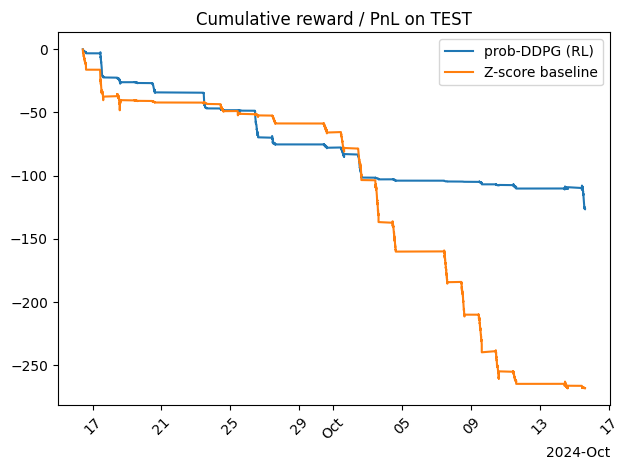

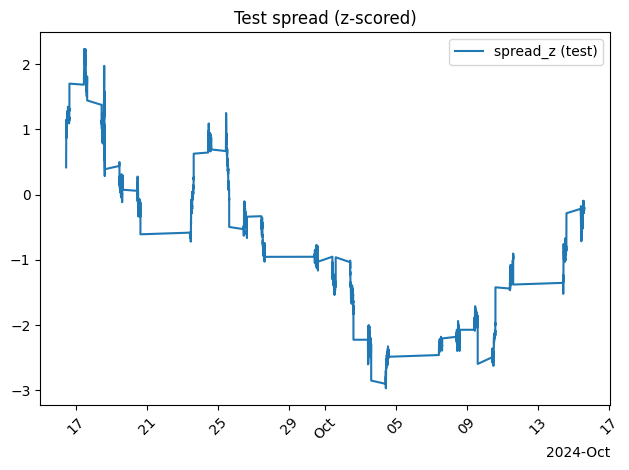

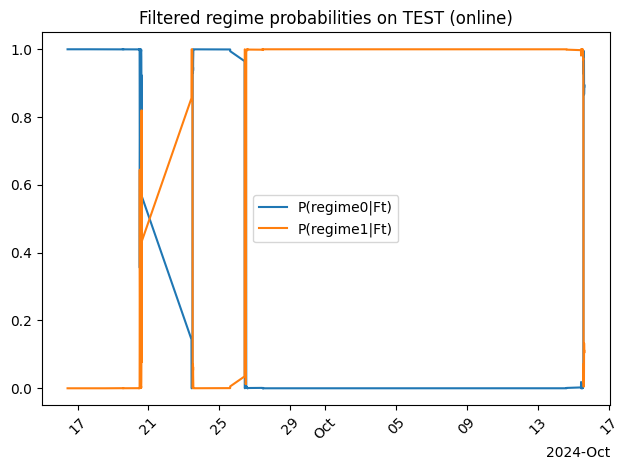

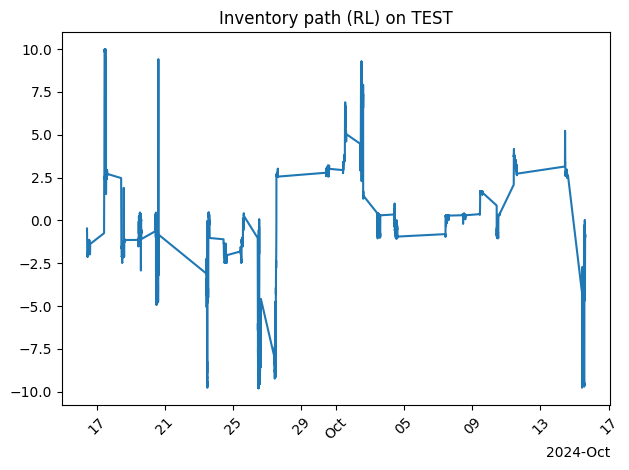

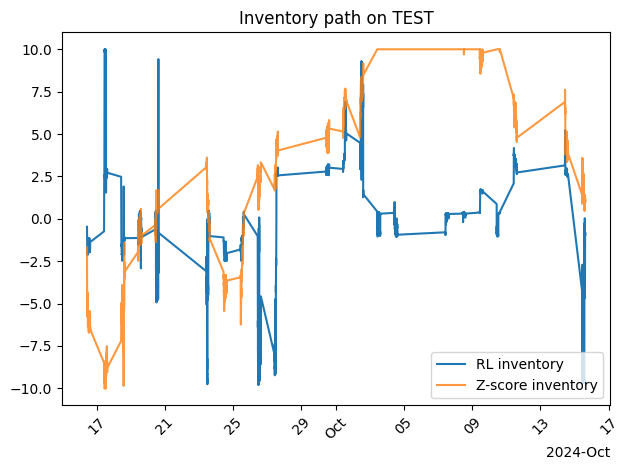

In [ ]:
fig, ax = plt.subplots()

ax.plot(ts[:len(cum_pnl)], cum_pnl, label="prob-DDPG (RL)")
ax.plot(ts[:len(z_cum)], z_cum, label="Z-score baseline")

ax.set_title("Cumulative reward / PnL on TEST")
ax.legend()

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots()

ax.plot(ts[:len(spreads)], spreads, label="spread_z (test)")
ax.set_title("Test spread (z-scored)")
ax.legend()

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots()

probs = np.asarray(probs)  
T, K = probs.shape
t_plot = ts[:T]

for k in range(K):
    ax.plot(t_plot, probs[:, k], label=f"P(regime{k}|Ft)")

ax.set_title("Filtered regime probabilities on TEST (online)")
ax.legend()

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots()

ax.plot(ts[:len(inventories)], inventories)
ax.set_title("Inventory path (RL) on TEST")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots()

ax.plot(ts[:len(inventories)], inventories, label="RL inventory")

ax.plot(ts[:len(z_I)], z_I, label="Z-score inventory", alpha=0.8)

ax.set_title("Inventory path on TEST")
ax.legend()

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

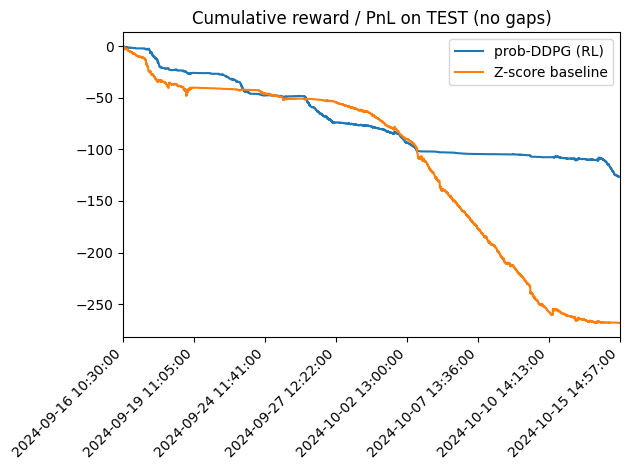

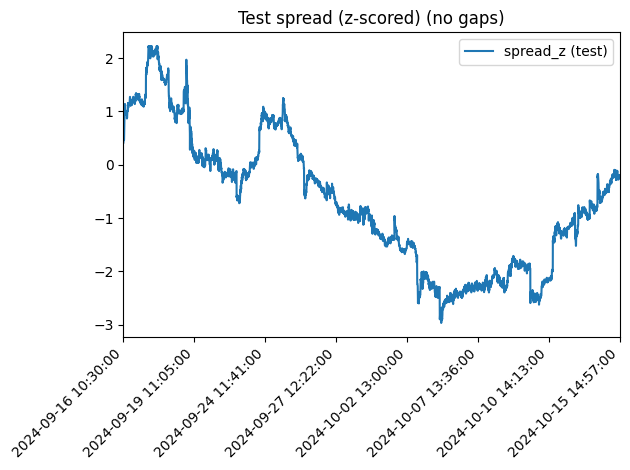

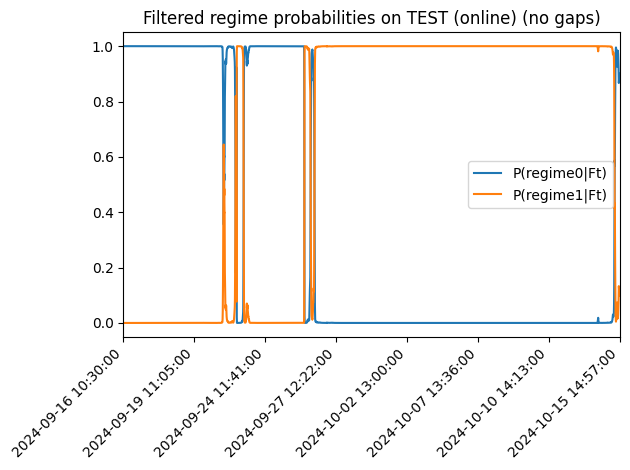

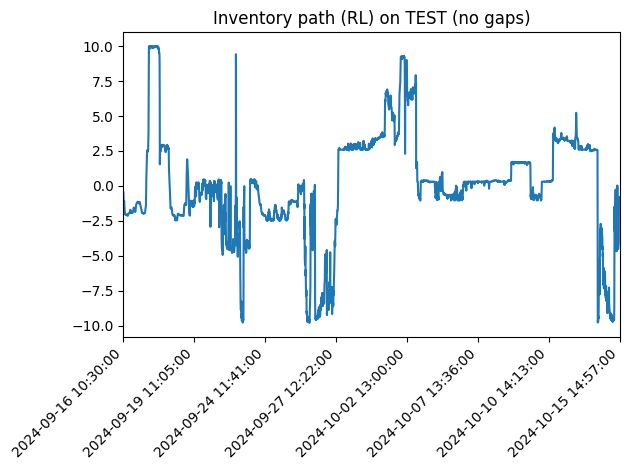

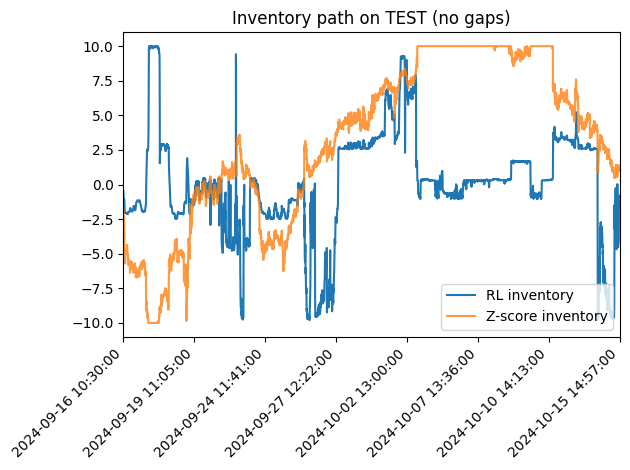

In [ ]:
import matplotlib.ticker as mticker


def no_gap_axis(ax, ts, max_labels=8):
    N = len(ts)
    x = np.arange(N)

    nlab = min(max_labels, N)
    tick_locs = np.linspace(0, N - 1, nlab, dtype=int)
    tick_labels = [str(ts[i]) for i in tick_locs]

    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right")
    ax.set_xlim(0, N - 1)
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    return x


fig, ax = plt.subplots()

N = min(len(ts), len(cum_pnl), len(z_cum))
ts_ng = ts[:N]
x = no_gap_axis(ax, ts_ng)

ax.plot(x, cum_pnl[:N], label="prob-DDPG (RL)")
ax.plot(x, z_cum[:N], label="Z-score baseline")

ax.set_title("Cumulative reward / PnL on TEST (no gaps)")
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots()

N = min(len(ts), len(spreads))
ts_ng = ts[:N]
x = no_gap_axis(ax, ts_ng)

ax.plot(x, spreads[:N], label="spread_z (test)")
ax.set_title("Test spread (z-scored) (no gaps)")
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots()

probs_arr = np.asarray(probs)
T, K = probs_arr.shape
N = min(len(ts), T)
ts_ng = ts[:N]
x = no_gap_axis(ax, ts_ng)

for k in range(K):
    ax.plot(x, probs_arr[:N, k], label=f"P(regime{k}|Ft)")

ax.set_title("Filtered regime probabilities on TEST (online) (no gaps)")
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots()

N = min(len(ts), len(inventories))
ts_ng = ts[:N]
x = no_gap_axis(ax, ts_ng)

ax.plot(x, inventories[:N])
ax.set_title("Inventory path (RL) on TEST (no gaps)")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots()

N = min(len(ts), len(inventories), len(z_I))
ts_ng = ts[:N]
x = no_gap_axis(ax, ts_ng)

ax.plot(x, inventories[:N], label="RL inventory")
ax.plot(x, z_I[:N], label="Z-score inventory", alpha=0.8)

ax.set_title("Inventory path on TEST (no gaps)")
ax.legend()

plt.tight_layout()
plt.show()

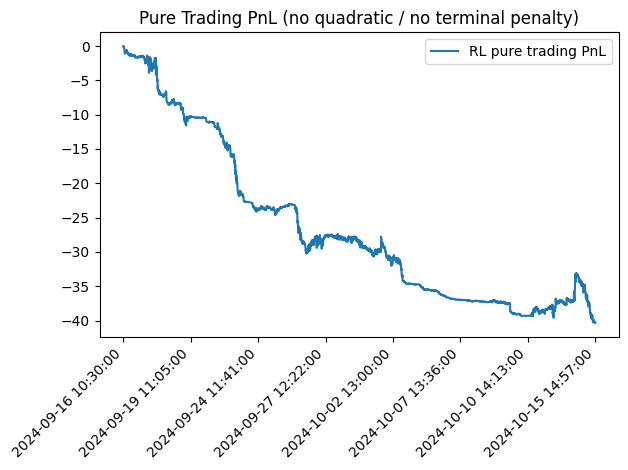

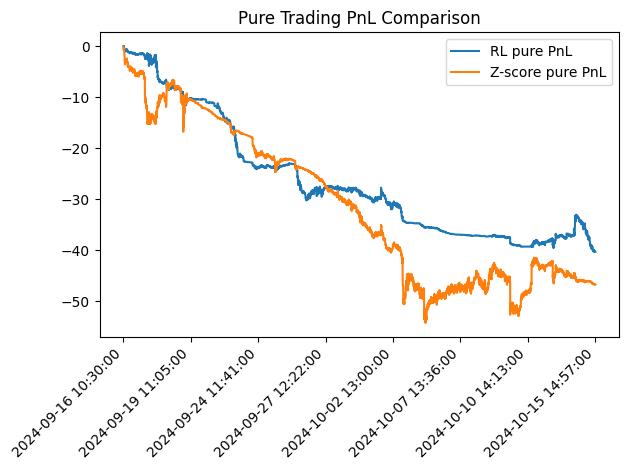

In [ ]:
def compute_pure_trading_pnl(spreads, inventories, trading_costs=0.05):
    spreads = np.asarray(spreads, dtype=float)
    inventories = np.asarray(inventories, dtype=float)

    dS = np.diff(np.concatenate(([spreads[0]], spreads)))

    pnl_step = []
    I_prev = 0.0

    for t in range(len(inventories)):
        I_curr = inventories[t]
        q = I_curr - I_prev

        pnl = I_curr * dS[t] - trading_costs * abs(q)
        pnl_step.append(pnl)

        I_prev = I_curr

    pnl_step = np.asarray(pnl_step, dtype=float)
    pnl_cum = np.cumsum(pnl_step)

    return pnl_cum, pnl_step


pnl_cum_pure, pnl_step_pure = compute_pure_trading_pnl(
    spreads,
    inventories,
    trading_costs=trading_costs,
)

fig, ax = plt.subplots()

N = min(len(ts), len(pnl_cum_pure))
x = np.arange(N)

ax.plot(x, pnl_cum_pure[:N], label="RL pure trading PnL")

ax.set_title("Pure Trading PnL (no quadratic / no terminal penalty)")
ax.legend()

nlab = min(8, N)
tick_locs = np.linspace(0, N - 1, nlab, dtype=int)
tick_labels = [str(ts[i]) for i in tick_locs]

ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()

z_pnl_cum_pure, z_pnl_step_pure = compute_pure_trading_pnl(
    spreads=z_test.values[: len(z_I)],
    inventories=z_I,
    trading_costs=trading_costs,
)

fig, ax = plt.subplots()

N = min(len(pnl_cum_pure), len(z_pnl_cum_pure))
x = np.arange(N)

ax.plot(x, pnl_cum_pure[:N], label="RL pure PnL")
ax.plot(x, z_pnl_cum_pure[:N], label="Z-score pure PnL")

ax.set_title("Pure Trading PnL Comparison")
ax.legend()

nlab = min(8, N)
tick_locs = np.linspace(0, N - 1, nlab, dtype=int)
tick_labels = [str(ts[i]) for i in tick_locs]

ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()